## Time to get you hands dirty!  Position of a star

You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
 

In [35]:
import numpy as np
import pylab as plt
import random
from scipy.stats import norm

In [36]:
N = 5
sigma = 0.2
mu = 1
np.random.seed(42)   # This way, you will get the same random values everytime you run the code.
gauss = norm(loc = mu , scale = sigma)    # M which is the model we are using.
sample = np.sort(gauss.rvs(N))        # Fake measures (original sample)  

- Plot each of the individual likelihoods separately.


#### Now, create parameters ($\theta$ = `measures`) that simulate your original `sample`.

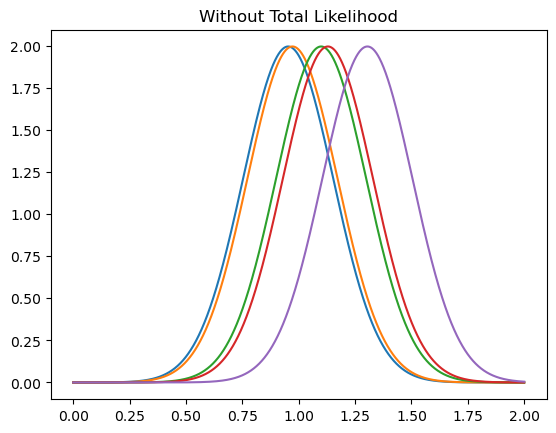

In [37]:
measures = np.linspace(1-5*sigma, 1+5*sigma,10000)    # Estimated measures out of the Fake measures distribution

pdf = [norm(loc = i, scale = sigma).pdf(measures) for i in sample ]
 
for i in range(len(pdf)):
    plt.plot(measures, pdf[i])
plt.title('Without Total Likelihood');

- Plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`)

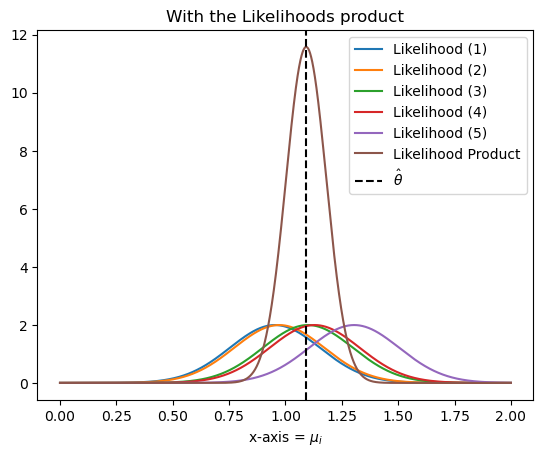

In [38]:
pdf = np.array(pdf)
Lh = np.prod(np.array(pdf), axis=0)


sorted = np.argsort(Lh)
index_max = sorted[-1]


for i in range(len(pdf)):
    plt.plot(measures, pdf[i], label = f'Likelihood ({i+1})')
plt.plot(measures,Lh, label= 'Likelihood Product')
plt.axvline(measures[sorted[-1]], color = 'black', ls = '--', label = '$\hat\\theta$')  # I did the second step here (ML)
plt.legend()
plt.xlabel('x-axis = $\mu_i$')
plt.title('With the Likelihoods product');


- Compare it with the MLE estimator derived above

In [39]:
data_mean = np.mean(sample)
print(f'The Maximum Likelihood estimate (from the plot) is {measures[sorted[-1]]}, \n while the estimator value (from the original data) {data_mean}')

The Maximum Likelihood estimate (from the plot) is 1.0917091709170919, 
 while the estimator value (from the original data) 1.0918005948650173


### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then flip and take the square root.

In [40]:
sod = np.diff(np.log(Lh), n =2)  # second order differentiation.

sod /= -1*(measures[1]-measures[0])**2    # Think about it as the binwidth.
sigma_fisher = 1/np.sqrt(sod[index_max])

- Compare with the Fisher matrix error derived above

In [41]:
error = sigma/np.sqrt(N)
print(f"The theoretical error formula  = {error}")
print(f"My rough differentiation error = {sigma_fisher}")

The theoretical error formula  = 0.08944271909999159
My rough differentiation error = 0.08944271910418103


- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees)

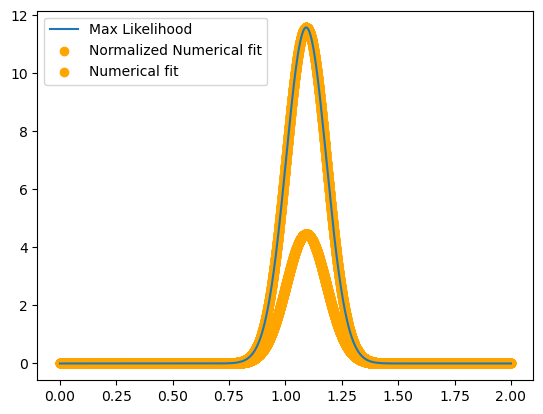

In [42]:
numerical = norm(loc = data_mean,scale = sigma_fisher)

constant = Lh.max()/numerical.pdf(measures).max()     # Normalization. 

plt.plot(measures,Lh, label = 'Max Likelihood')
plt.scatter(measures, constant*numerical.pdf(measures) ,c= 'orange', label = 'Normalized Numerical fit') 
plt.scatter(measures, numerical.pdf(measures) ,c= 'orange', label = 'Numerical fit')

plt.legend();

### Part 3 (optional; not examinable)

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

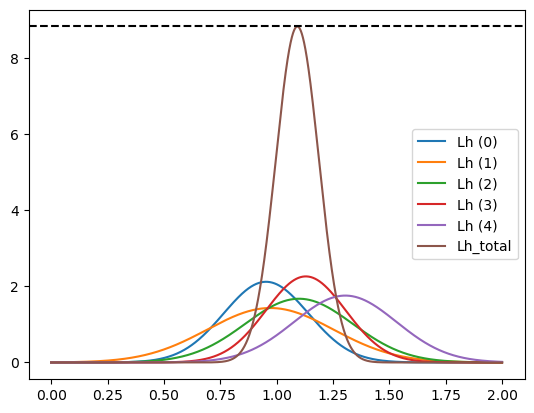

In [43]:
sigma_list = norm(loc = sigma, scale = 0.05).rvs(N)
pdf_list = [norm(loc = i, scale = j).pdf(measures) for i,j in zip(sample,sigma_list) ]
Lh_total = np.prod(pdf_list,axis=0)


for i in range(len(pdf_list)):
    plt.plot(measures,pdf_list[i], label = f'Lh ({i})')
plt.plot(measures, Lh_total, label= f'Lh_total')
plt.axhline(Lh_total.max(), c = 'black', ls = 'dashed')
plt.legend();

# Run the last code multiple times and see the change in the total Likelihood Maximum.

In [44]:
maximum = np.argsort(Lh_total)[-1]

sod = np.diff(np.log(Lh_total), n =2)  # second order differentiation.

sod /= -1*(measures[1]-measures[0])**2    # Think about it as the binwidth.
s_fisher = 1/np.sqrt(sod[index_max])

In [45]:
t_sigma = 1/np.sqrt(np.sum((1/sigma_list)**2))
print('The averge sigma = ',np.sum(sigma_list)/len(sigma_list))
print('Minimum sigma = ',sigma_list.min())
s_fisher

The averge sigma =  0.22185596245362132
Minimum sigma =  0.1765262807032524


np.float64(0.09528984929539658)